In [1]:
import torch

import sys
sys.path.append('../src')
from data_utils import get_nsf_data_proc
from model_utils import get_model
from eval_utils import Metrics, evaluate_model

ROOT_DIR = '/shared_data0/weiqiuy/nsf-awards'
debug = True

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [3]:
# model_name = 'unsloth/Qwen2.5-7B'
model_name = 'unsloth/Meta-Llama-3.1-8B'
model, tokenizer = get_model(model_name, mode='eval')

model_name_lora = f'{ROOT_DIR}/models/lora_model_{model_name.split("/")[1]}'
model_lora, tokenizer = get_model(model_name_lora, mode='eval')

==((====))==  Unsloth 2025.1.7: Fast Llama patching. Transformers: 4.48.1.
   \\   /|    GPU: NVIDIA RTX A6000. Max memory: 47.428 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.4.0+cu118. CUDA: 8.6. CUDA Toolkit: 11.8. Triton: 3.0.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.27.post2+cu118. FA2 = False]
 "-____-"     Free Apache license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
==((====))==  Unsloth 2025.1.7: Fast Llama patching. Transformers: 4.48.1.
   \\   /|    GPU: NVIDIA RTX A6000. Max memory: 47.428 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.4.0+cu118. CUDA: 8.6. CUDA Toolkit: 11.8. Triton: 3.0.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.27.post2+cu118. FA2 = False]
 "-____-"     Free Apache license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth 2025.1.7 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


In [4]:
train_dataset, test_dataset = get_nsf_data_proc(ROOT_DIR, tokenizer, mode='tech2nontech')

DatasetDict({
    train: Dataset({
        features: ['award_id', 'technical_abstract', 'non_technical_abstract', 'verifiable_claims', 'investigation_proposals', 'award_year', 'division', 'directorate', 'title', 'publications'],
        num_rows: 11527
    })
})
dict_keys(['award_id', 'technical_abstract', 'non_technical_abstract', 'verifiable_claims', 'investigation_proposals', 'award_year', 'division', 'directorate', 'title', 'publications'])
Train dataset: Dataset({
    features: ['award_id', 'technical_abstract', 'non_technical_abstract', 'verifiable_claims', 'investigation_proposals', 'award_year', 'division', 'directorate', 'title', 'publications'],
    num_rows: 9221
})
Test dataset: Dataset({
    features: ['award_id', 'technical_abstract', 'non_technical_abstract', 'verifiable_claims', 'investigation_proposals', 'award_year', 'division', 'directorate', 'title', 'publications'],
    num_rows: 2306
})


Map:   0%|          | 0/9221 [00:00<?, ? examples/s]

Map:   0%|          | 0/2306 [00:00<?, ? examples/s]

# Eval

In [5]:
results = evaluate_model(model, tokenizer, test_dataset, debug=debug)
results_lora = evaluate_model(model_lora, tokenizer, test_dataset, debug=debug)

  0%|          | 0/2306 [00:00<?, ?it/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/2306 [00:00<?, ?it/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
import os
debug = True
save_dir = 'results/tech2nontech'
if debug:
    save_dir += '_debug'
os.makedirs(save_dir, exist_ok=True)
torch.save(results, os.path.join(save_dir, model_name.split('/')[-1] + '.pt'))
torch.save(results_lora, os.path.join(save_dir, model_name_lora.split('/')[-1] + '.pt'))

# Show results

In [25]:
load_dir = 'results/tech2nontech'
if debug:
    load_dir += '_debug'
model_names = [
    'unsloth/Qwen2.5-7B'
]
lora_model_names = [f'{ROOT_DIR}/models/lora_model_{model_name.split("/")[1]}' 
                    for model_name in model_names]

all_model_basenames = [model_name.split('/')[-1] for model_name in model_names] + \
    [model_name.split('/')[-1] for model_name in lora_model_names]

In [26]:
results_all = {}
for model_basename in all_model_basenames:
    results_all[model_basename] = torch.load(os.path.join(load_dir, model_basename + '.pt'))

/tmp/ipykernel_4449/2571787635.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  results_all[model_basename] = torch.load(os.path.join(load_dir, model_basename + '.pt'))


In [30]:
import numpy as np
import random
import matplotlib.pyplot as plt

def bootstrap_std(values, n_bootstrap=1000, seed=42):
    """
    Compute bootstrap-based standard deviation of the mean.
    values: 1D list or array of metric values.
    n_bootstrap: number of bootstrap samples.
    seed: random seed for reproducibility.
    """
    random.seed(seed)
    values = np.array(values)
    means = []
    n = len(values)
    
    for _ in range(n_bootstrap):
        # Sample with replacement
        sample = np.random.choice(values, size=n, replace=True)
        means.append(np.mean(sample))
        
    return np.std(means)

def aggregate_and_analyze(results):
    """
    Takes a list of result dicts and returns a dictionary of
    {metric_name: (mean, std)} pairs. 
    """
    # Prepare containers for each metric
    metrics = {
        "bertscore_precision": [],
        "bertscore_recall": [],
        "bertscore_f1": [],
        "rouge1": [],
        "rouge2": [],
        "rougeL": [],
        "rougeLsum": [],
        "bleu": []
    }
    
    # Aggregate all values
    for res in results:
        # BERTScore can come in lists; extend or append accordingly
        metrics["bertscore_precision"].extend(res["bertscore"]["precision"])
        metrics["bertscore_recall"].extend(res["bertscore"]["recall"])
        metrics["bertscore_f1"].extend(res["bertscore"]["f1"])
        
        # ROUGE are single floats
        metrics["rouge1"].append(res["rouge"]["rouge1"])
        metrics["rouge2"].append(res["rouge"]["rouge2"])
        metrics["rougeL"].append(res["rouge"]["rougeL"])
        metrics["rougeLsum"].append(res["rouge"]["rougeLsum"])
        
        # BLEU is also a single float
        metrics["bleu"].append(res["bleu"]["bleu"])
    
    # Now compute mean and bootstrap std for each metric
    analysis = {}
    for metric_name, values in metrics.items():
        mean_val = np.mean(values)
        std_val = bootstrap_std(values, n_bootstrap=1000, seed=42)
        analysis[metric_name] = (mean_val, std_val)
    
    return analysis

# Re-defining the function and running it again

import numpy as np
import matplotlib.pyplot as plt

def plot_grouped_bar(results):
    """
    Given the results dictionary {model_name: {metric_name: (mean, std)}},
    create a grouped bar plot with error bars for each metric.
    """
    models = list(results.keys())
    metrics = list(next(iter(results.values())).keys())

    means = {metric: [results[model][metric][0] for model in models] for metric in metrics}
    stds = {metric: [results[model][metric][1] for model in models] for metric in metrics}

    x = np.arange(len(metrics))  # Label locations
    width = 0.35  # Width of bars

    fig, ax = plt.subplots(figsize=(12, 6))

    for i, model in enumerate(models):
        ax.bar(x + i * width, [means[m][i] for m in metrics], width, 
               yerr=[stds[m][i] for m in metrics], capsize=5, label=model, alpha=0.7)

    ax.set_xlabel('Metrics')
    ax.set_ylabel('Score')
    ax.set_title('Mean Scores with Bootstrap Std for Different Models')
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(metrics, rotation=45, ha='right')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [28]:
results_all_aggr = {}
for key in results_all:
    aggr_results = aggregate_and_analyze(results_all[key])
    results_all_aggr[key] = aggr_results

In [29]:
results_all_aggr

{'Qwen2.5-7B': {'bertscore_precision': (0.8553886140386263,
   0.006218352456314751),
  'bertscore_recall': (0.8456324537595113, 0.0033429438121759096),
  'bertscore_f1': (0.850278397401174, 0.003954377040924142),
  'rouge1': (0.28649520990648486, 0.016468346433960543),
  'rouge2': (0.08424830204783962, 0.020002792021767416),
  'rougeL': (0.1816599301515093, 0.016302650233262293),
  'rougeLsum': (0.18344146149234977, 0.01786162358067834),
  'bleu': (0.03276715360273693, 0.009809209922979152)},
 'lora_model_Qwen2.5-7B': {'bertscore_precision': (0.8614330540100733,
   0.005576529305750451),
  'bertscore_recall': (0.8505966613690058, 0.00405018621976209),
  'bertscore_f1': (0.8557963048418363, 0.004137390860311095),
  'rouge1': (0.32500016792728387, 0.0210772909786088),
  'rouge2': (0.1000466676795226, 0.022731844213839388),
  'rougeL': (0.20352634468377814, 0.019856333605916345),
  'rougeLsum': (0.20465502212007972, 0.01906951198245005),
  'bleu': (0.040553531676690575, 0.011783000287018

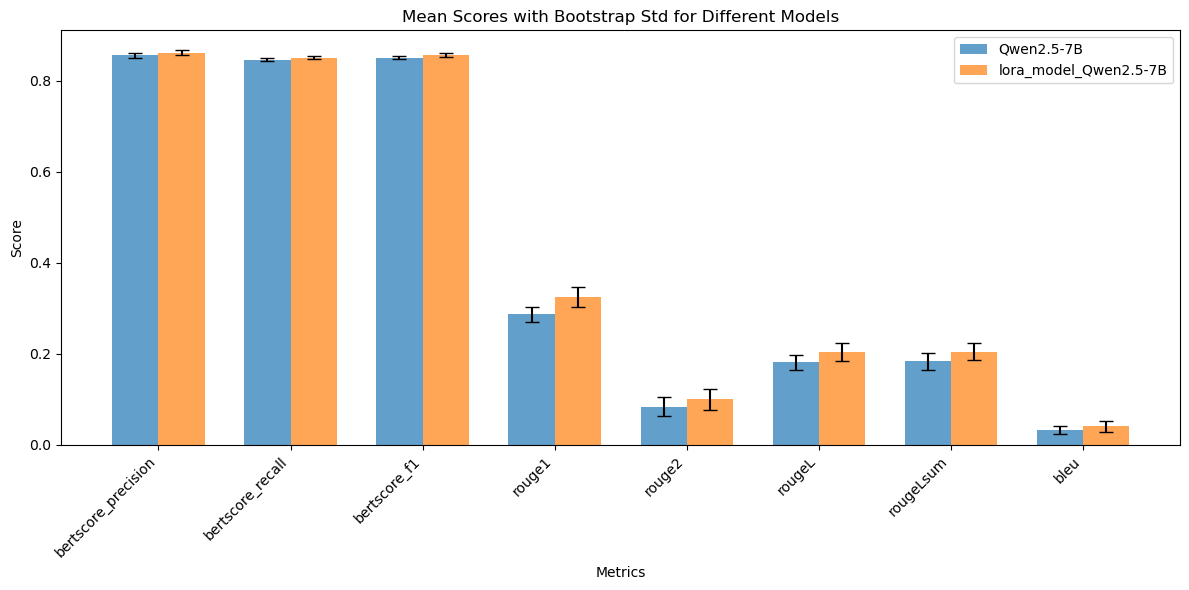

In [31]:
plot_grouped_bar(results_all_aggr)